# Subplot Tutorial: Matplotlib & Plotly Express

This notebook walks you through creating **subplots**, multiple charts in a single figure using three of Python's most popular visualization libraries:

| Library | Style | Interactivity |
|---|---|---|
| **Matplotlib** | Low-level, fully customizable | Static |
| **Seaborn** | Statistical, beautiful defaults | Static |
| **Plotly Express** | High-level, modern | Interactive |


## Setup & Sample Data

In [1]:
# !pip install matplotlib seaborn plotly pandas numpy

In [1]:
import numpy as np
import pandas as pd
from itertools import product as cartesian_product
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Seed for reproducibility
np.random.seed(42)

In [2]:
# Sample Data Generation

months = pd.date_range('2023-01', periods=24, freq='ME')
products = ['Laptop', 'Phone', 'Tablet']
data_grid = list(cartesian_product(months, products))
df = pd.DataFrame(data_grid, columns=['month', 'product'])

n_rows = len(df)
df['sales'] = np.random.randint(50, 300, n_rows)
df['revenue'] = np.random.uniform(10000, 80000, n_rows)
df['profit'] = np.random.uniform(2000, 20000, n_rows)
df['region'] = np.random.choice(['North', 'South', 'East', 'West'], n_rows)
df['rating'] = np.random.uniform(3.0, 5.0, n_rows).round(1)

wide = df.pivot_table(index='month', columns='product',
                      values='sales', aggfunc='sum').reset_index()

print(f'Dataset shape: {df.shape}')
display(df.head(6))

Dataset shape: (72, 7)


,month,product,sales,revenue,profit,region,rating
0,2023-01-31,Laptop,152,26162.567794,12779.578397,South,3.7
1,2023-01-31,Phone,229,26871.782622,14506.128795,East,4.5
2,2023-01-31,Tablet,142,57828.446318,17848.421102,East,4.4
3,2023-02-28,Laptop,64,52699.766045,13238.372866,South,3.6
4,2023-02-28,Phone,156,68323.643822,7321.406345,South,4.1
5,2023-02-28,Tablet,121,22135.525746,3898.896677,East,4.0


## Single Plot vs. Subplots

When visualizing data, you often have to choose between putting everything on one chart or splitting them up. Here is how to decide:

#### 1. Single Plots (`plt.plot`, `plt.bar`, etc.)
*   **Best for:** Comparing different categories on the same scale (e.g., Sales of 3 products over time).
*   **Pros:** Easy to see intersections and direct comparisons.
*   **Cons:** Can become 'spaghetti-like' and messy if there are too many lines or categories.

#### 2. Subplots (`plt.subplots`)
*   **Best for:** Showing different *types* of data at once (e.g., a line chart for trends next to a histogram for distribution).
*   **Pros:** Keeps the dashboard organized; allows for different Y-axis scales (Revenue vs. Units).
*   **Cons:** Harder to compare exact values across different boxes if they aren't 'shared'.


### The "State-Machine" vs "Object-Oriented" API

*   **State-Machine (Simple):** Uses `plt.title()`, `plt.xlabel()`. It's like drawing on a single piece of paper. Whatever you call applies to the *current* active plot.
*   **Object-Oriented (Subplots):** Uses `ax.set_title()`, `ax.set_xlabel()`. It's like having multiple sticky notes. You specifically tell Matplotlib *which* note (`ax`) you are writing on.

### Example Single Plot

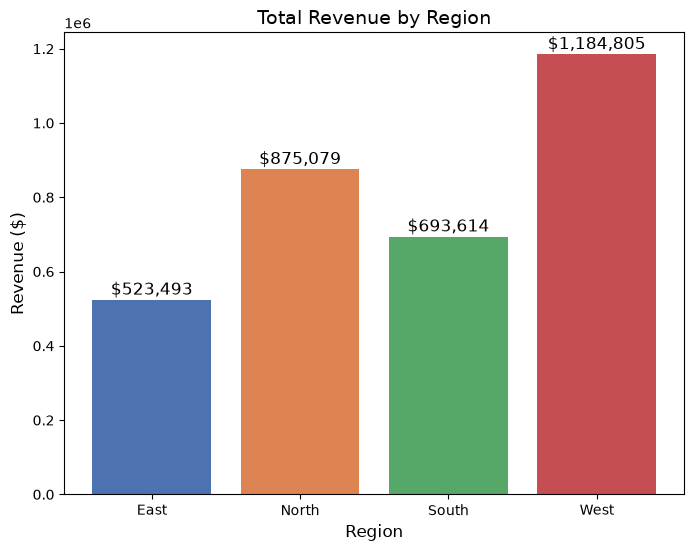

In [3]:
plt.figure(figsize=(8, 6))
region_revenue = df.groupby('region')['revenue'].sum()
bars = plt.bar(region_revenue.index, region_revenue.values,
              color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.title('Total Revenue by Region', fontsize = 14)
plt.xlabel('Region', fontsize = 12)
plt.ylabel('Revenue ($)', fontsize = 12)
plt.bar_label(bars, fmt='${:,.0f}', padding=1, fontsize=12)
plt.show()

### Example Subplot

Text(0.5, 0.98, 'Matplotlib - Example Subplot')

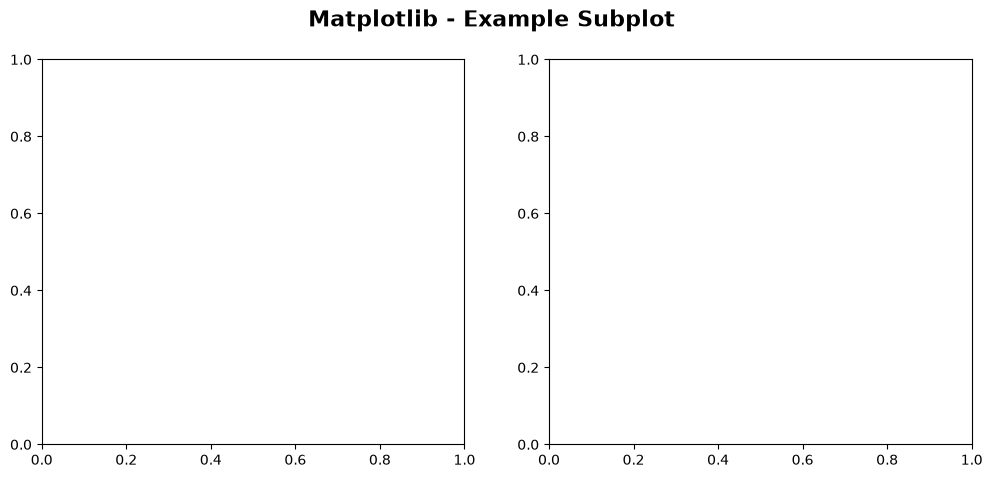

In [4]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

fig.suptitle('Matplotlib - Example Subplot', fontsize=16, fontweight='bold')

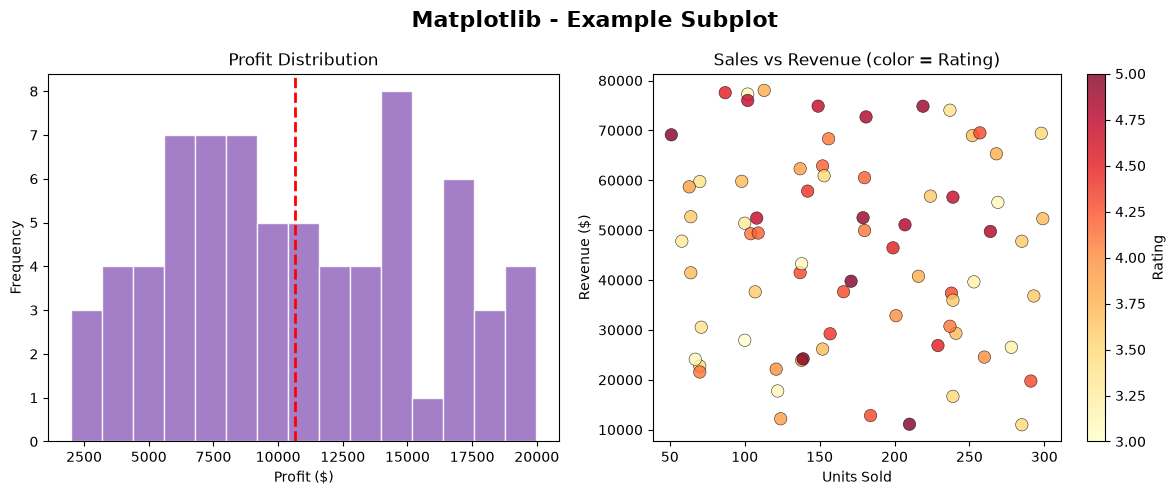

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

fig.suptitle('Matplotlib - Example Subplot', fontsize=16, fontweight='bold')

ax = axes[0]
ax.hist(df['profit'], bins=15, color='#9467BD', edgecolor='white', alpha=0.85)
ax.axvline(df['profit'].mean(), color='red', linestyle='--', linewidth=2,
           label=f"Mean: ${df['profit'].mean():,.0f}")
ax.set_title('Profit Distribution')
ax.set_xlabel('Profit ($)')
ax.set_ylabel('Frequency')


ax = axes[1]
scatter = ax.scatter(df['sales'], df['revenue'],
                     c=df['rating'], cmap='YlOrRd', s=80, alpha=0.8, edgecolors='k', linewidths=0.4)
plt.colorbar(scatter, ax=ax, label='Rating')
ax.set_title('Sales vs Revenue (color = Rating)')
ax.set_xlabel('Units Sold')
ax.set_ylabel('Revenue ($)')

plt.tight_layout()
plt.show()

## Matplotlib Subplots

Matplotlib is the **foundation** of Python plotting. Its `plt.subplots()` function returns a `Figure` and an array of `Axes` objects that you plot on individually.


### Basic 2×2 Grid

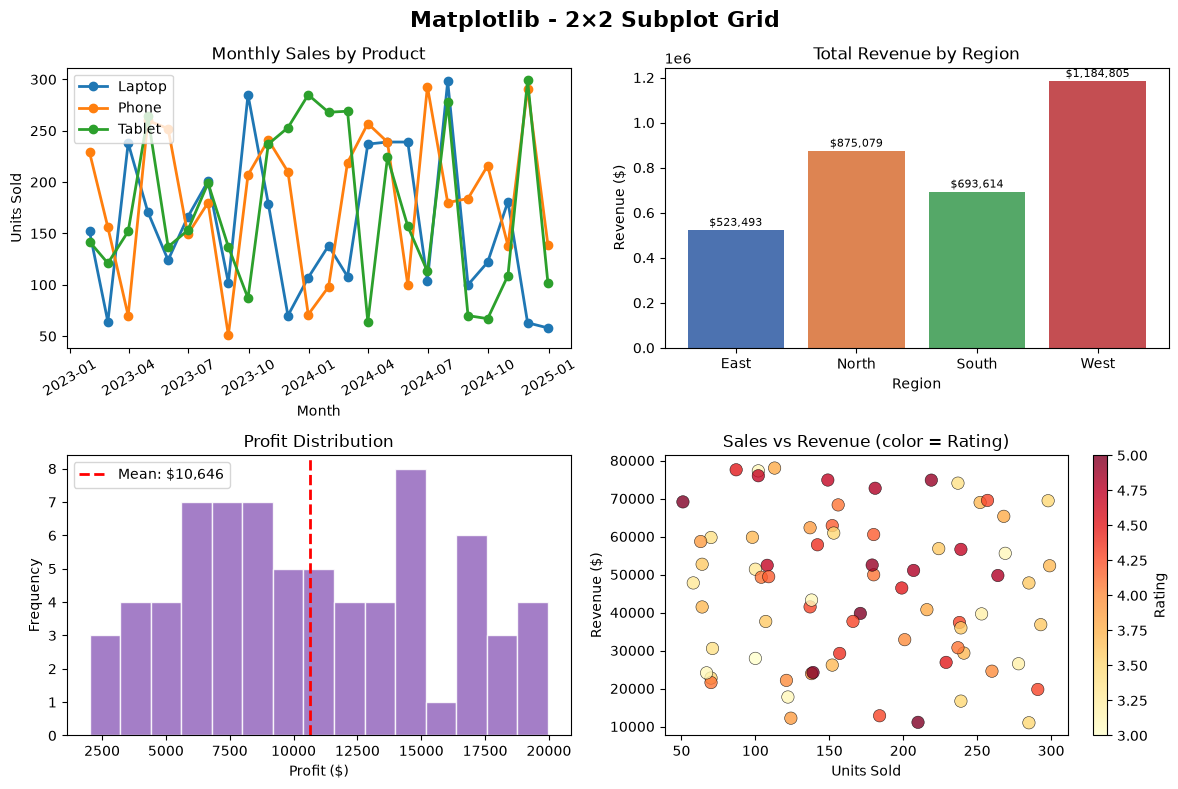

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

fig.suptitle('Matplotlib - 2×2 Subplot Grid', fontsize=16, fontweight='bold')


# Top-left: Line chart
ax = axes[0, 0]
for product in wide.columns[1:]:
    ax.plot(wide['month'], wide[product], marker='o', label=product, linewidth=2)
ax.set_title('Monthly Sales by Product')
ax.set_xlabel('Month')
ax.set_ylabel('Units Sold')
ax.legend(loc = "upper left")
ax.tick_params(axis='x', rotation=30)


# Top-right: Bar chart
ax = axes[0, 1]
region_revenue = df.groupby('region')['revenue'].sum()
bars = ax.bar(region_revenue.index, region_revenue.values,
              color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
ax.set_title('Total Revenue by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Revenue ($)')
ax.bar_label(bars, fmt='${:,.0f}', padding=1, fontsize=8)


# Bottom-left: Histogram
ax = axes[1, 0]
ax.hist(df['profit'], bins=15, color='#9467BD', edgecolor='white', alpha=0.85)
ax.axvline(df['profit'].mean(), color='red', linestyle='--', linewidth=2,
           label=f"Mean: ${df['profit'].mean():,.0f}")
ax.set_title('Profit Distribution')
ax.set_xlabel('Profit ($)')
ax.set_ylabel('Frequency')
ax.legend()


# Bottom-right: Scatter plot
ax = axes[1, 1]
scatter = ax.scatter(df['sales'], df['revenue'],
                     c=df['rating'], cmap='YlOrRd', s=80, alpha=0.8, edgecolors='k', linewidths=0.4)
plt.colorbar(scatter, ax=ax, label='Rating')
ax.set_title('Sales vs Revenue (color = Rating)')
ax.set_xlabel('Units Sold')
ax.set_ylabel('Revenue ($)')

plt.tight_layout()
plt.show()

### 2.2 Sharing Axes

Use `sharex=True` or `sharey=True` to link axes - zooming/panning one updates all.

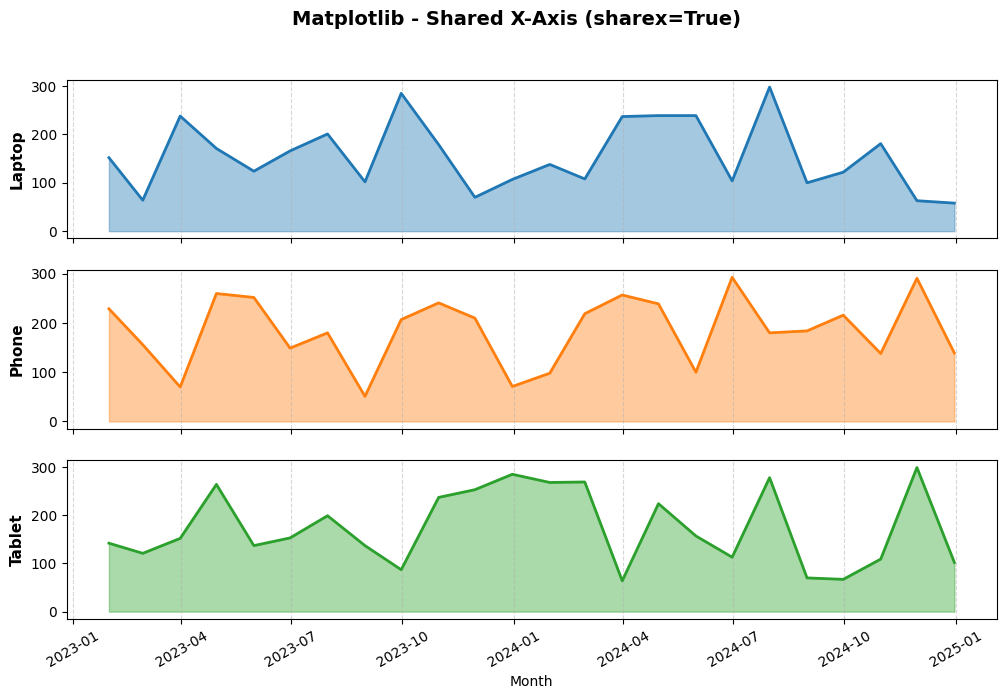

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7),
                         sharex=True,          # shared x-axis
                         )

fig.suptitle('Matplotlib - Shared X-Axis (sharex=True)', fontsize=14, fontweight='bold')

products = ['Laptop', 'Phone', 'Tablet']
colors   = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, (product, color) in enumerate(zip(products, colors)):
    prod_data = df[df['product'] == product].sort_values('month')
    axes[i].fill_between(prod_data['month'], prod_data['sales'],
                         alpha=0.4, color=color)
    axes[i].plot(prod_data['month'], prod_data['sales'],
                 color=color, linewidth=2)
    axes[i].set_ylabel(product, fontsize=11, fontweight='bold')
    axes[i].grid(axis='x', linestyle='--', alpha=0.5)

axes[-1].set_xlabel('Month')
axes[-1].tick_params(axis='x', rotation=30)

plt.show()

### 2.3 Custom Grid with GridSpec

`GridSpec` lets you build **unequal** subplot layouts - different row/column spans.

/tmp/ipykernel_3419/1297777287.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_bm.boxplot([df[df['region']==r]['profit'].values for r in ['North','South','East','West']],


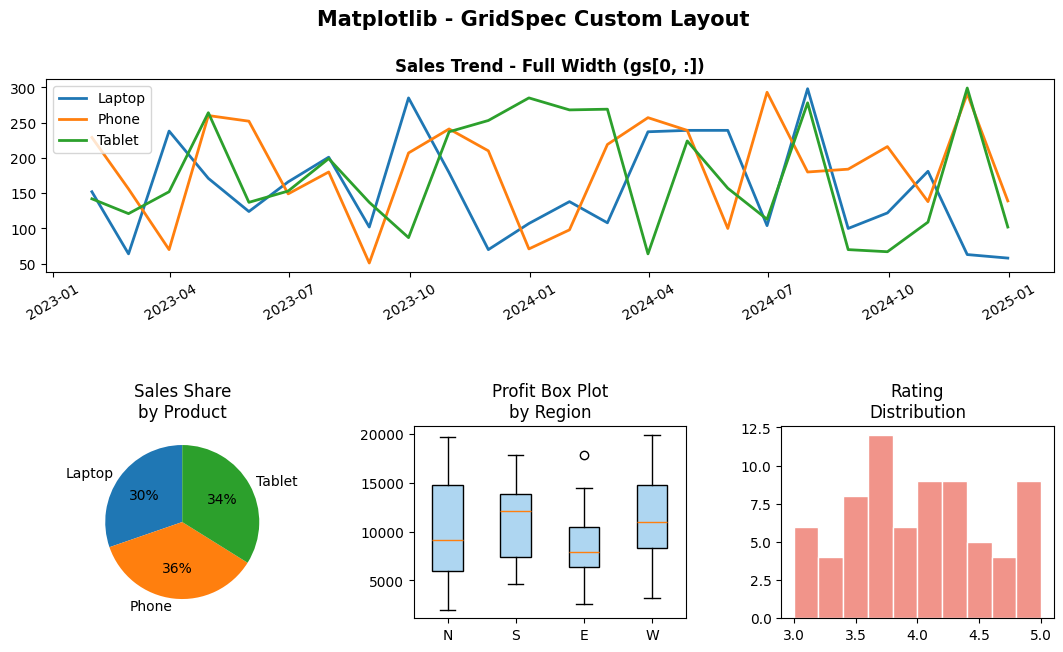

In [8]:
fig = plt.figure(figsize=(13, 7))
gs  = gridspec.GridSpec(2, 3, figure=fig,
                        hspace=0.8, wspace=0.35)

# Wide top chart spanning all 3 columns
ax_top = fig.add_subplot(gs[0, :])         # row 0, all columns
ax_top.plot(wide['month'], wide['Laptop'], label='Laptop', lw=2)
ax_top.plot(wide['month'], wide['Phone'],  label='Phone',  lw=2)
ax_top.plot(wide['month'], wide['Tablet'], label='Tablet', lw=2)
ax_top.set_title('Sales Trend - Full Width (gs[0, :])', fontweight='bold')
ax_top.legend(); ax_top.tick_params(axis='x', rotation=30)

# Three smaller charts in the second row
region_groups = df.groupby('region')

ax_bl = fig.add_subplot(gs[1, 0])
ax_bl.pie(df.groupby('product')['sales'].sum(),
          labels=df['product'].unique(), autopct='%1.0f%%', startangle=90)
ax_bl.set_title('Sales Share\nby Product')

ax_bm = fig.add_subplot(gs[1, 1])
ax_bm.boxplot([df[df['region']==r]['profit'].values for r in ['North','South','East','West']],
              labels=['N','S','E','W'], patch_artist=True,
              boxprops=dict(facecolor='#AED6F1'))
ax_bm.set_title('Profit Box Plot\nby Region')

ax_br = fig.add_subplot(gs[1, 2])
ax_br.hist(df['rating'], bins=10, color='#F1948A', edgecolor='white')
ax_br.set_title('Rating\nDistribution')

fig.suptitle('Matplotlib - GridSpec Custom Layout', fontsize=15, fontweight='bold')
plt.show()

## Plotly Express Subplots <a id='4-plotly'></a>

Plotly produces **interactive** charts. For subplots, we use `make_subplots()` from `plotly.subplots` and add Plotly Express traces to each cell.

### Basic Interactive 2×2 Grid

In [9]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Sales by Product (Line)',
        'Revenue by Region (Bar)',
        'Profit Distribution (Histogram)',
        'Sales vs Revenue (Scatter)'
    ),
    vertical_spacing=0.12,
    horizontal_spacing=0.10
)

# Row 1, Col 1: Line
colors_map = {'Laptop': '#636EFA', 'Phone': '#EF553B', 'Tablet': '#00CC96'}
for product, color in colors_map.items():
    prod_data = df[df['product'] == product].sort_values('month')
    fig.add_trace(
        go.Scatter(x=prod_data['month'], y=prod_data['sales'],
                   mode='lines+markers', name=product,
                   line=dict(color=color, width=2),
                   legendgroup=product),
        row=1, col=1
    )

# Row 1, Col 2: Bar
region_rev = df.groupby('region')['revenue'].sum().reset_index()
fig.add_trace(
    go.Bar(x=region_rev['region'], y=region_rev['revenue'],
           marker_color=['#AB63FA','#FFA15A','#19D3F3','#FF6692'],
           showlegend=False),
    row=1, col=2
)

# Row 2, Col 1: Histogram
fig.add_trace(
    go.Histogram(x=df['profit'], nbinsx=15,
                 marker_color='#62b00e', showlegend=False),
    row=2, col=1
)
fig.update_layout(bargap=0.2)

# Row 2, Col 2: Scatter
for product, color in colors_map.items():
    subset = df[df['product'] == product]
    fig.add_trace(
        go.Scatter(x=subset['sales'], y=subset['revenue'],
                   mode='markers',
                   name=product,
                   marker=dict(color=color, size=9, opacity=0.7),
                   legendgroup=product,
                   showlegend=False),
        row=2, col=2
    )

fig.update_layout(
    title_text='<b>Plotly - Interactive 2×2 Subplot Grid</b>',
    height=650, width=950,
    template='plotly_white',
    legend_title_text='Product'
)

fig.show()

### Plotly Mixed Sized Grid

In [10]:
fig = make_subplots(
    rows=2, cols=3,
    specs=[
        [{'type': 'bar'},   {'type': 'scatter'}, {'type': 'pie'}],
        [{'colspan': 2, 'type': 'scatter'}, None, {'type': 'bar'}]
    ],
    subplot_titles=(
        'Avg Profit by Region',
        'Rating vs Profit',
        'Revenue Share',
        'Sales Timeline (all products)',
        '',
        'Top Regions by Sales'
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.08
)

# Row 1 Col 1 - Bar
avg_profit = df.groupby('region')['profit'].mean().reset_index()
fig.add_trace(go.Bar(x=avg_profit['region'], y=avg_profit['profit'],
                     marker_color='#636EFA', showlegend=False), row=1, col=1)

# Row 1 Col 2 - Scatter
fig.add_trace(go.Scatter(x=df['rating'], y=df['profit'],
                         mode='markers',
                         marker=dict(color=df['sales'], colorscale='Viridis',
                                     size=8, opacity=0.8),
                         showlegend=False), row=1, col=2)

# Row 1 Col 3 - Pie
rev_share = df.groupby('product')['revenue'].sum().reset_index()
fig.add_trace(go.Pie(labels=rev_share['product'], values=rev_share['revenue'],
                     hole=0.35), row=1, col=3)

# Row 2 Col 1-2 - Full-width line
for product, color in colors_map.items():
    d = df[df['product']==product].sort_values('month')
    fig.add_trace(go.Scatter(x=d['month'], y=d['sales'],
                             mode='lines+markers', name=product,
                             line=dict(color=color, width=2)),
                  row=2, col=1)

# Row 2 Col 3 - Bar
top_sales = df.groupby('region')['sales'].sum().reset_index().sort_values('sales')
fig.add_trace(go.Bar(x=top_sales['sales'], y=top_sales['region'],
                     orientation='h',
                     marker_color='#00CC96', showlegend=False), row=2, col=3)

fig.update_layout(
    title_text='<b>Plotly - Full Dashboard Layout with colspan</b>',
    height=700, width=1050,
    template='plotly_white',
    legend_title='Product'
)
fig.show()